# SVM Classification with New Workflow

**Complete pipeline with proper naming:**
1. **Training** → `training_*` ROIs train the SVM
2. **Classification** → SVM outputs `classified_*` predictions
3. **Filtering** → Small clusters become `filtered_*`
4. **Merge** → `filtered_* + classified_sediment` → `new_sediment`
5. **Validation** → Compare 3 classes against `validation_*` ROIs

**Key features:**
- ✅ Clear naming throughout the pipeline
- ✅ No empty strings - all pixels classified
- ✅ Can visualize 5-class filtered map
- ✅ Morphological operations disabled

## Setup and Import

In [1]:
import importlib
import sys
import os
import numpy as np

sys.path.append(os.path.abspath("../"))

from utils.gref_pipeline import georef
from gref_pipeline import config

importlib.reload(georef)
from utils.gref_pipeline.georef import *

print("✅ Module loaded successfully!")

✅ Module loaded successfully!


## Load Data and ROIs

In [2]:
# Load transect
transect = load_transect(config.OUTPUT_FOLDER)
transect.list_files()

# Select file
cube = transect.select_files(["rad_uhi_20241029_115057_5"])
cube.describe()


📋 Files in output (corrected=False):
 1. rad_uhi_20241029_115057_1  | shape=(1333, 968, 210)  | has_georef=True
 2. rad_uhi_20241029_115057_2  | shape=(1946, 968, 210)  | has_georef=True
 3. rad_uhi_20241029_115057_3  | shape=(2227, 968, 210)  | has_georef=True
 4. rad_uhi_20241029_115057_4  | shape=(2463, 968, 210)  | has_georef=True
 5. rad_uhi_20241029_115057_5  | shape=(2462, 968, 210)  | has_georef=True
 6. rad_uhi_20241029_115057_6  | shape=(155, 968, 210)  | has_georef=True
🔄 Rebuilding grids from georef hits for selected files...
   • rad_uhi_20241029_115057_5
  rad_uhi_20241029_115057_5: Using GRIDDED format (T=2462, S=968)
✅ Combined shapes: X/Y/Z (2462, 968), RGB (2462, 968)
🔄 Loading full hyperspectral cube...
   • Loading rad_uhi_20241029_115057_5...
✅ Loaded full cube: (2462, 968, 210) (T × S × B)

=== Combined_output ===
Tracks × Slits: 2462 × 968
RGB coverage: R/G/B finite ratios 1.00/1.00/1.00

📋 File boundaries:
  rad_uhi_20241029_115057_5: tracks 0–2461 (2462)


In [3]:
# Apply illumination correction
cube.apply_illumination_correction_v2()

🔄 Using V2 algorithm (pandas rolling median)
✅ Illumination correction already applied with window=500, strength=1.0
   Loading from disk...
📂 Loading saved illumination correction from 1 files...
   rad_uhi_20241029_115057_5: window=500, strength=1.0
✅ Loaded illumination correction from disk


array([[[2.2304249e+00, 1.6764377e+00, 0.0000000e+00, ...,
         0.0000000e+00, 7.0077596e+00, 0.0000000e+00],
        [7.4757171e+00, 8.5974735e-01, 0.0000000e+00, ...,
         0.0000000e+00, 3.0958059e+00, 0.0000000e+00],
        [1.8294926e+00, 2.3438740e+00, 0.0000000e+00, ...,
         0.0000000e+00, 7.1090145e+00, 0.0000000e+00],
        ...,
        [1.7213115e+00, 1.4317783e+00, 0.0000000e+00, ...,
         1.0000000e+00, 2.3279436e-02, 3.7040919e-01],
        [5.8812752e+00, 2.0123754e+00, 0.0000000e+00, ...,
         0.0000000e+00, 1.4956644e+00, 0.0000000e+00],
        [2.3867478e+00, 1.0000000e+00, 0.0000000e+00, ...,
         0.0000000e+00, 1.5736811e+01, 4.5105180e-01]],

       [[2.2304249e+00, 7.7452070e-01, 3.9940205e+00, ...,
         0.0000000e+00, 0.0000000e+00, 9.6023534e-05],
        [1.7471981e+00, 0.0000000e+00, 1.2654871e+00, ...,
         0.0000000e+00, 8.5029960e-01, 6.3767982e-01],
        [1.9216584e+00, 0.0000000e+00, 3.0771544e+00, ...,
         0.000

In [4]:
# Import ROIs
cube.import_rois("./ROIs/057_5_combined.json")
cube.list_rois()

📂 Imported 6 ROIs from ./ROIs/057_5_combined.json

📂 ROI Collection (6 ROIs):
 1. 'validation_dark': 358 pixels
     Slit range:  174 - 740
     Track range: 729 - 1416
 2. 'validation_bombs': 454 pixels
     Slit range:  244 - 880
     Track range: 593 - 1547
 3. 'validation_sediment': 273 pixels
     Slit range:   14 - 870
     Track range: 577 - 1580
 4. 'training_dark': 364 pixels
     Slit range:   24 - 962
     Track range:  23 - 2420
 5. 'training_sediment': 398 pixels
     Slit range:   31 - 924
     Track range:  51 - 2417
 6. 'training_bombs': 201 pixels
     Slit range:  513 - 794
     Track range: 2136 - 2416


In [5]:
# Define ROI collections
training_rois = [
    "training_dark",
    "training_sediment",
    "training_bombs",
]

validation_rois = [
    "validation_dark",
    "validation_sediment",
    "validation_bombs",
]

print(f"Training ROIs: {training_rois}")
print(f"Validation ROIs: {validation_rois}")

Training ROIs: ['training_dark', 'training_sediment', 'training_bombs']
Validation ROIs: ['validation_dark', 'validation_sediment', 'validation_bombs']


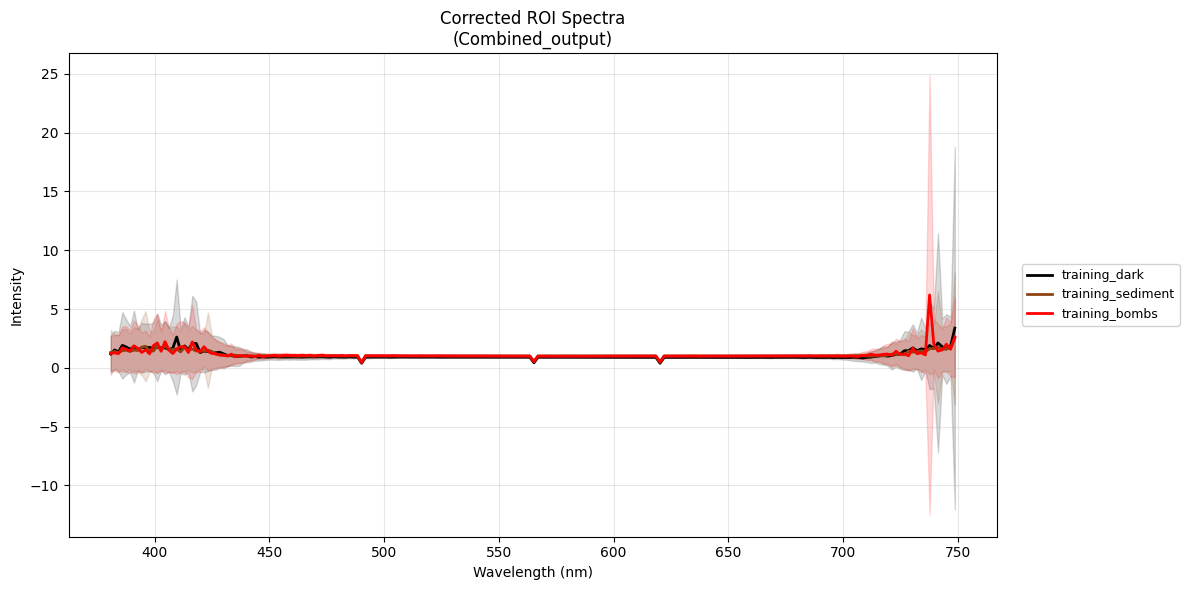

In [18]:
# Plot preprocessed spectra (no additional processing - already done)
cube.plot_spectrum(
    roi_names=training_rois,
    use_corrected=True,
    wavelength_range=None,  # Already cropped in memory
    # wavelength_smoothing=1,  # Already smoothed in memory
    interpolate_wavelengths=None,  # Already interpolated in memory
    normalize_method=None,  # Already normalized in memory
    legend_loc="outside",
    use_inline_labels=False,
    show_std=True,
)

💡 Interactive mode: Click on the plot to display coordinates


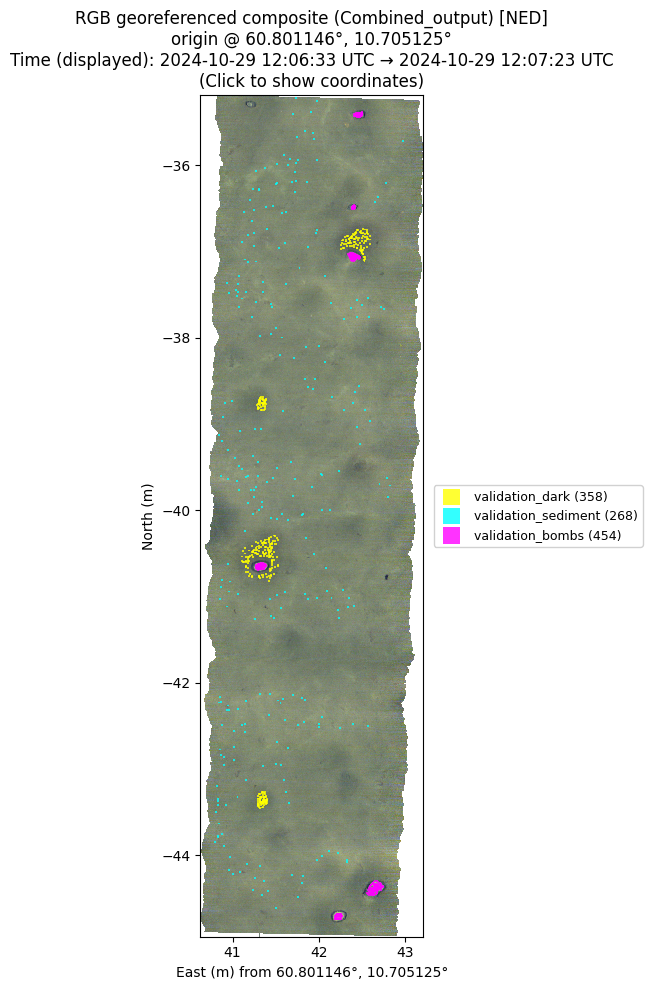

In [6]:
# Plot validation ROIs
%matplotlib inline

cube.plot_georef(
    apply_alignment_shift=True,
    use_corrected=True,
    coordinate_system="NED",
    track_start=config.UHI_TRACK_RANGE_5[0],
    track_end=config.UHI_TRACK_RANGE_5[1],
    figsize=(30, 10),
    roi_collection=validation_rois,
    roi_marker_size=2,
    roi_legend_loc="outside",
    roi_marker_edgewidth=0,
    roi_legend_markersize=50,
)

## Train SVM with Cross-Validation

In [7]:
# Train SVM with spatial cross-validation
cv_results = cube.train_svm_with_cv(
    training_rois=training_rois,
    segment_start=config.UHI_TRACK_RANGE_5[0],
    segment_end=config.UHI_TRACK_RANGE_5[1],
    wavelength_range=(490, 680),
    cv_folds=5,
    use_corrected=True,
    svm_kernel="rbf",
    optimize_params=True,
    add_brightness_feature=False,
    quiet=False,
)

# Print summary
print(f"\n" + "=" * 60)
print(f"📊 CROSS-VALIDATION SUMMARY")
print(f"=" * 60)
print(
    f"Accuracy:  {cv_results['cv_mean_metrics']['accuracy_mean']:.3f} ± {cv_results['cv_mean_metrics']['accuracy_std']:.3f}"
)
print(
    f"Precision: {cv_results['cv_mean_metrics']['precision_mean']:.3f} ± {cv_results['cv_mean_metrics']['precision_std']:.3f}"
)
print(
    f"Recall:    {cv_results['cv_mean_metrics']['recall_mean']:.3f} ± {cv_results['cv_mean_metrics']['recall_std']:.3f}"
)
print(
    f"F1 Score:  {cv_results['cv_mean_metrics']['f1_mean']:.3f} ± {cv_results['cv_mean_metrics']['f1_std']:.3f}"
)

print(f"\n🎯 Best hyperparameters:")
print(f"  C = {cv_results['best_params']['C']}")
print(f"  gamma = {cv_results['best_params']['gamma']}")

print(f"\n📍 Training pixels used:")
for class_name, count in cv_results["training_pixels_per_class"].items():
    print(f"  {class_name}: {count} pixels")

🤖 SVM TRAINING WITH CROSS-VALIDATION
💡 MODE: Standard spectral classification

� Wavelength filtering:
   Range: 490 - 680 nm
   Wavelengths used: 108 (from 210)

�📦 Datacube shape: (2462, 968, 108)
📏 Using data: corrected
🎯 Segment range: tracks 576 to 1566
📍 Training ROIs: ['training_dark', 'training_sediment', 'training_bombs']

🔍 Filtering ROI pixels...
   training_dark: 364 pixels (rejected 0 inside segment)
   training_sediment: 397 pixels (rejected 1 inside segment)
   training_bombs: 201 pixels (rejected 0 inside segment)

✅ Training data: 962 pixels, 108 features
   Features: 108 wavelengths
   Kept (outside segment): 962
   Rejected (inside segment): 1

🔬 Creating spatial groups for CV...
   Settings: closing_radius=3, min_group_size=20
   Sediment grid: 100(slit) × 200(track) px, min=10
   training_dark: 364 pixels → 6 groups via connected_components
      dark#A: 119 pixels
      dark#B: 50 pixels
      dark#C: 37 pixels
      dark#D: 29 pixels
      dark#E: 51 pixels
     

💡 Interactive mode: Click on the plot to display coordinates


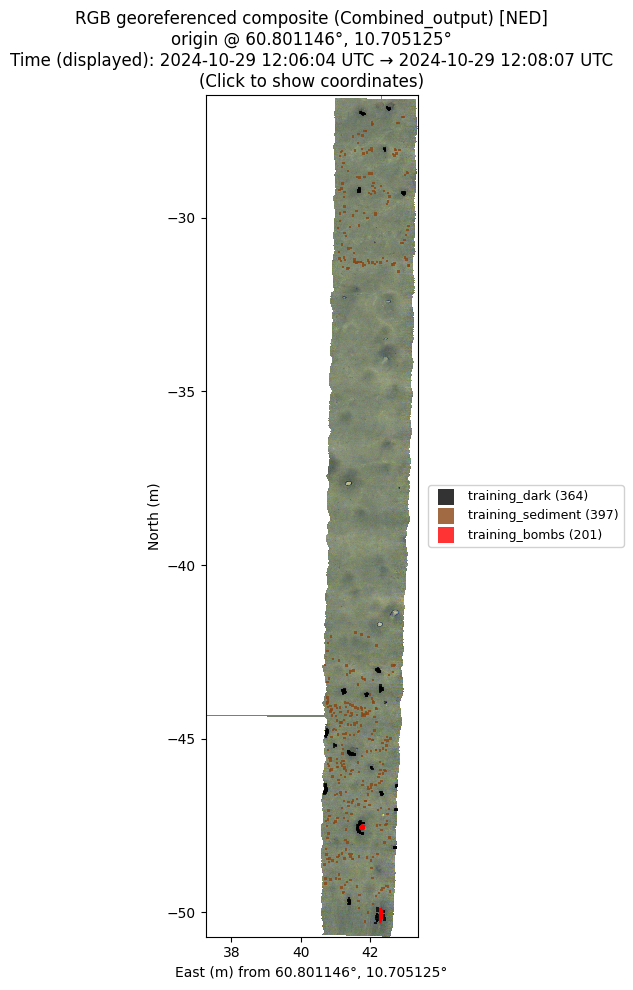

In [8]:
# Visualize filtered training ROIs
cube.plot_georef(
    use_corrected=True,
    figsize=(40, 10),
    roi_collection=cv_results["filtered_training_rois"],
    roi_marker_size=3,
    roi_legend_loc="outside",
    roi_marker_edgewidth=0,
    roi_legend_markersize=40,
)

💡 Interactive mode: Click on the plot to display coordinates


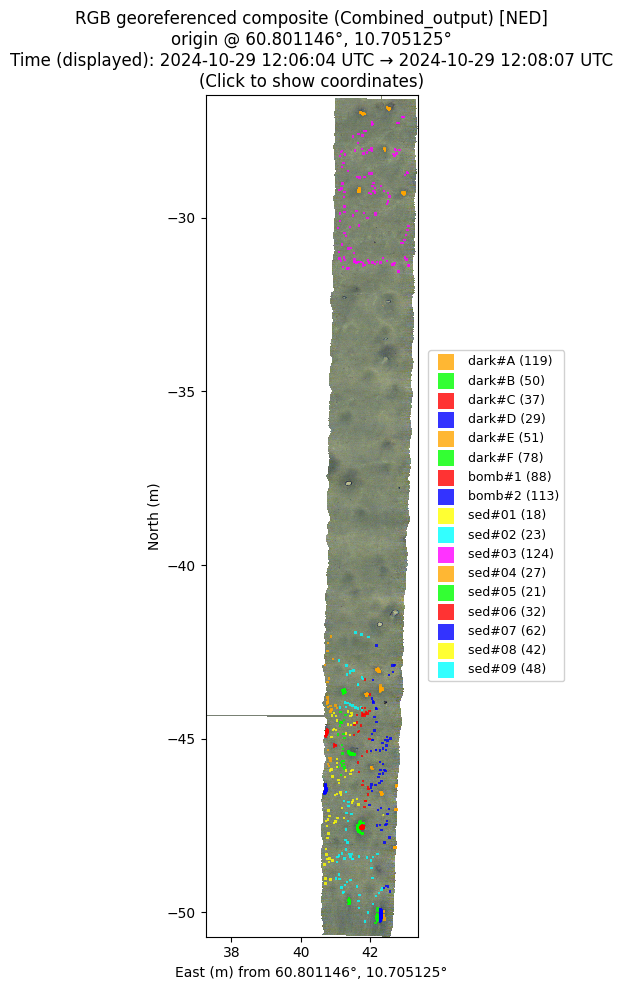


📊 Spatial Groups Created:
   bomb#1: 88 pixels
   bomb#2: 113 pixels
   dark#A: 119 pixels
   dark#B: 50 pixels
   dark#C: 37 pixels
   dark#D: 29 pixels
   dark#E: 51 pixels
   dark#F: 78 pixels
   sed#01: 18 pixels
   sed#02: 23 pixels
   sed#03: 124 pixels
   sed#04: 27 pixels
   sed#05: 21 pixels
   sed#06: 32 pixels
   sed#07: 62 pixels
   sed#08: 42 pixels
   sed#09: 48 pixels


In [9]:
# Plot spatial groups created during training
if (
    "spatial_groups_roi_collection" in cv_results
    and cv_results["spatial_groups_roi_collection"]
):
    cube.plot_georef(
        use_corrected=True,
        figsize=(40, 10),
        roi_collection=cv_results["spatial_groups_roi_collection"],
        roi_marker_size=3,
        roi_legend_loc="outside",
        roi_marker_edgewidth=0,
        roi_legend_markersize=40,
    )

    # Print group info
    print("\n📊 Spatial Groups Created:")
    for group_name, pixels in sorted(
        cv_results["spatial_groups_roi_collection"].items()
    ):
        print(f"   {group_name}: {len(pixels)} pixels")
else:
    print(
        "⚠️ No spatial groups found in cv_results. Training may not have used spatial clustering."
    )

## STEP 1: Classification (outputs classified_*)

In [10]:
# Classify segment - outputs classified_bombs, classified_dark, classified_sediment
print("🎯 STEP 1: CLASSIFICATION")
print("=" * 60)

classification_results = cube.classify_segment(
    segment_start=config.UHI_TRACK_RANGE_5[0],
    segment_end=config.UHI_TRACK_RANGE_5[1],
    use_corrected=True,
    quiet=False,
    confidence_threshold=0.5,  # ✅ NEW: Reject low-confidence pixels
)

print(f"\n✅ Classification complete!")
print(f"   Classes: {classification_results['class_names']}")
print(f"\n📊 Pixel counts:")
for class_name in classification_results["class_names"]:
    count = np.sum(classification_results["classification_map"] == class_name)
    print(f"   {class_name}: {count} pixels")

🎯 STEP 1: CLASSIFICATION
🎯 SEGMENT CLASSIFICATION (no filtering, no validation)
🎲 Confidence threshold: 0.50
   (Pixels with max_prob < 0.50 → classified_unknown)
🎯 SEGMENT CLASSIFICATION WITH VALIDATION

📊 Using wavelength subset: 108 wavelengths

📦 Datacube shape: (2462, 968, 108)
📏 Using data: corrected
🎯 Segment range: tracks 576 to 1566

🔪 Extracting segment...
   Segment shape: (991, 968, 108)

🤖 Classifying 959288 pixels...


   Classifying: 100%|█████████████████████████████████| 959288/959288 [02:02<00:00, 7861.88pixels/s]



🎲 Confidence Thresholding:
   Threshold: 0.50
   Unknown pixels: 55448 (5.8%)
   Confidence range: [0.339, 1.000]
   ✅ Classification complete in 122.46 seconds

📊 Classification distribution (before filtering):
   classified_bombs: 1507 pixels (0.2%)
   classified_dark: 69351 pixels (7.2%)
   classified_sediment: 832982 pixels (86.8%)
   classified_unknown: 55448 pixels (5.8%)

✅ Classification and validation complete!

✅ Classification complete!
   Classes: ['classified_bombs', 'classified_dark', 'classified_sediment', 'classified_unknown']

📊 Pixel counts:
   classified_bombs: 1507 pixels
   classified_dark: 69351 pixels
   classified_sediment: 832982 pixels
   classified_unknown: 55448 pixels


📊 Plotting classification map (3 classes)...
ROIs created: ['classified_bombs', 'classified_dark', 'classified_sediment', 'classified_unknown']
💡 Interactive mode: Click on the plot to display coordinates


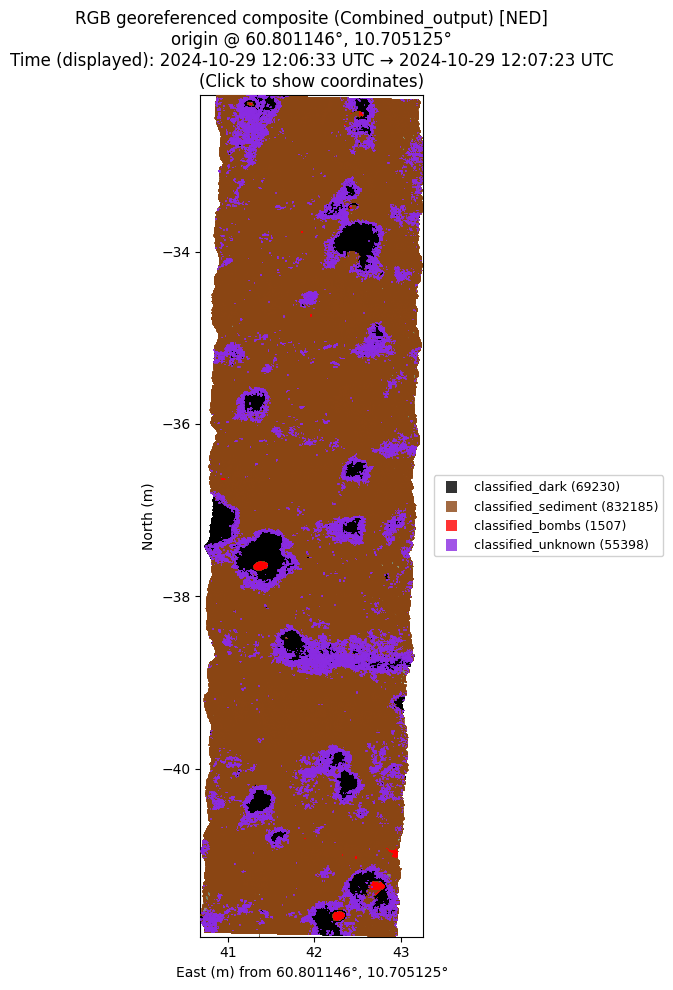

In [11]:
# Plot classification (3 classes)
print("📊 Plotting classification map (3 classes)...")

classification_rois = {}
for class_name in classification_results["class_names"]:
    mask = classification_results["classification_map"] == class_name
    rows, cols = np.where(mask)
    pixels = [(col, row + config.UHI_TRACK_RANGE_5[0]) for row, col in zip(rows, cols)]
    if len(pixels) > 0:
        classification_rois[class_name] = pixels

print(f"ROIs created: {list(classification_rois.keys())}")

cube.plot_georef(
    use_corrected=True,
    coordinate_system="NED",
    track_start=config.UHI_TRACK_RANGE_5[0],
    track_end=config.UHI_TRACK_RANGE_5[1],
    figsize=(40, 10),
    roi_collection=classification_rois,
    roi_marker_size=1,
    roi_legend_loc="outside",
    roi_marker_edgewidth=0,
    roi_legend_markersize=50,
)

## STEP 2: Filtering (creates filtered_*)

In [12]:
# Apply filtering - creates filtered_bombs and filtered_dark
print("\n🧹 STEP 2: FILTERING")
print("=" * 60)

filtering_results = cube.filter_classification(
    classification_map=classification_results["classification_map"],
    class_names=classification_results["class_names"],
    filter_bombs=True,
    filter_dark=True,
    filter_sediment=False,
    min_area_px=10,
    connectivity=8,
    morph_close_radius=0,  # Disabled
    morph_open_radius=0,  # Disabled
    merge_proximity_px=0,
    quiet=False,
)

print(f"\n✅ Filtering complete!")
print(f"   All classes after filtering: {filtering_results['all_classes']}")


🧹 STEP 2: FILTERING
🧹 POST-CLASSIFICATION FILTERING

🧹 POST-CLASSIFICATION FILTERING
   Classes to filter: ['classified_bombs', 'classified_dark']
   Connectivity: 8
   Min area: 10 pixels
   Morph close radius: 0 (disabled)
   Morph open radius: 0 (disabled)
   Merge proximity: 0 px (disabled)

   🔍 Filtering classified_bombs (bomb)...
      Found 57 connected components
      Kept: 6 components (1415 pixels)
      Removed: 51 components (92 pixels)
      ✂️  Reclassified 92 pixels as filtered_bombs
      Final: 1415 pixels (92 removed, 6.1%)

   🔍 Filtering classified_dark (dark)...
      Found 2012 connected components
      Kept: 190 components (65434 pixels)
      Removed: 1822 components (3917 pixels)
      ✂️  Reclassified 3917 pixels as filtered_dark
      Final: 65434 pixels (3917 removed, 5.6%)

✅ Post-classification filtering complete

📊 Filtering summary:
   classified_bombs: 92 pixels removed (6.1%)
      → Created filtered_bombs: 92 pixels
   classified_dark: 3917 pixels

📊 Plotting filtered map (5 classes: classified_* + filtered_*)...
ROIs created: ['classified_bombs', 'classified_dark', 'classified_sediment', 'classified_unknown', 'filtered_bombs', 'filtered_dark']

📊 Pixel counts:
   classified_bombs: 1415 pixels
   classified_dark: 65434 pixels
   classified_sediment: 832982 pixels
   classified_unknown: 55448 pixels
   filtered_bombs: 92 pixels
   filtered_dark: 3917 pixels
💡 Interactive mode: Click on the plot to display coordinates


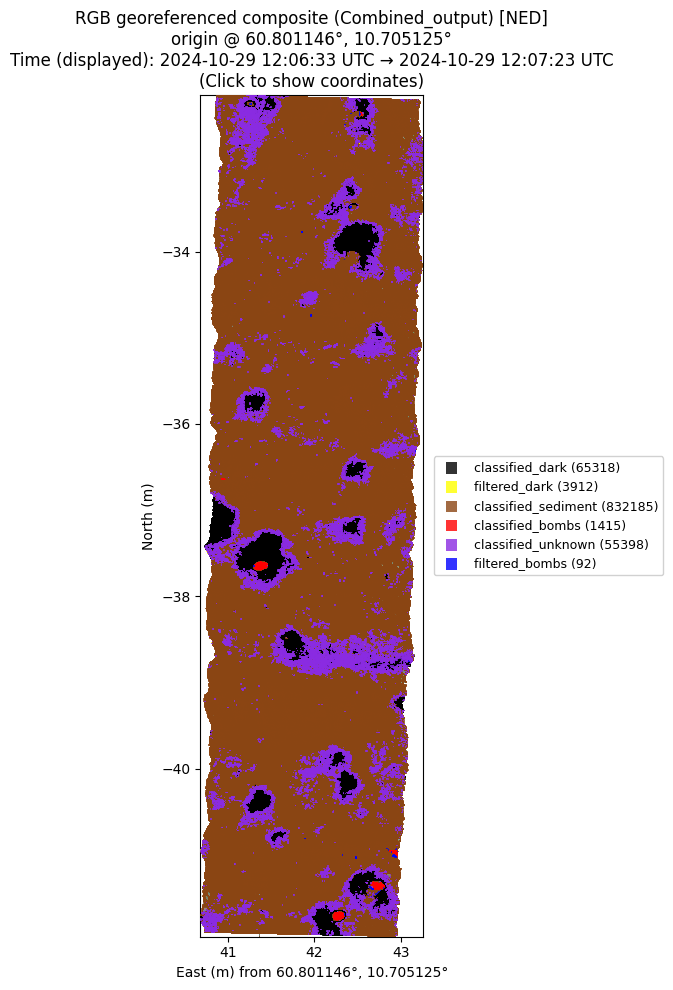

In [13]:
# Plot filtered map (5 classes!)
print("📊 Plotting filtered map (5 classes: classified_* + filtered_*)...")

filtered_rois = {}
for class_name in filtering_results["all_classes"]:
    mask = filtering_results["filtered_map"] == class_name
    rows, cols = np.where(mask)
    pixels = [(col, row + config.UHI_TRACK_RANGE_5[0]) for row, col in zip(rows, cols)]
    if len(pixels) > 0:
        filtered_rois[class_name] = pixels

print(f"ROIs created: {list(filtered_rois.keys())}")
print(f"\n📊 Pixel counts:")
for class_name in sorted(filtered_rois.keys()):
    print(f"   {class_name}: {len(filtered_rois[class_name])} pixels")

cube.plot_georef(
    use_corrected=True,
    coordinate_system="NED",
    track_start=config.UHI_TRACK_RANGE_5[0],
    track_end=config.UHI_TRACK_RANGE_5[1],
    figsize=(40, 10),
    roi_collection=filtered_rois,
    roi_marker_size=1,
    roi_legend_loc="outside",
    roi_marker_edgewidth=0,
    roi_legend_markersize=50,
)

## STEP 3: Merge to create new_sediment

In [14]:
# Merge filtered classes into new_sediment
print("\n🔀 STEP 3: MERGE FILTERED CLASSES")
print("=" * 60)

merge_results = cube.merge_filtered_to_sediment(
    filtered_map=filtering_results["filtered_map"],
    quiet=False,
)

print(f"\n✅ Merge complete!")
print(f"   Final classes for validation: {merge_results['class_names']}")


🔀 STEP 3: MERGE FILTERED CLASSES
🔀 MERGING FILTERED CLASSES TO SEDIMENT

📊 Before merge:
   classified_bombs: 1415 pixels
   classified_dark: 65434 pixels
   classified_sediment: 832982 pixels
   classified_unknown: 55448 pixels
   filtered_bombs: 92 pixels
   filtered_dark: 3917 pixels

🔀 Merged into new_sediment:
   classified_sediment: 832982 pixels
   filtered_bombs: 92 pixels
   filtered_dark: 3917 pixels
   ─────────────────────────
   Total: 836991 pixels

📊 After merge (3 classes for validation):
   classified_bombs: 1415 pixels
   classified_dark: 65434 pixels
   new_sediment: 836991 pixels

✅ Merge complete!
   Final classes for validation: ['classified_bombs', 'classified_dark', 'new_sediment']


📊 Plotting validation map (3 classes)...
ROIs created: ['classified_bombs', 'classified_dark', 'new_sediment']

📊 Pixel counts:
   classified_bombs: 1415 pixels
   classified_dark: 65434 pixels
   new_sediment: 836991 pixels
💡 Interactive mode: Click on the plot to display coordinates


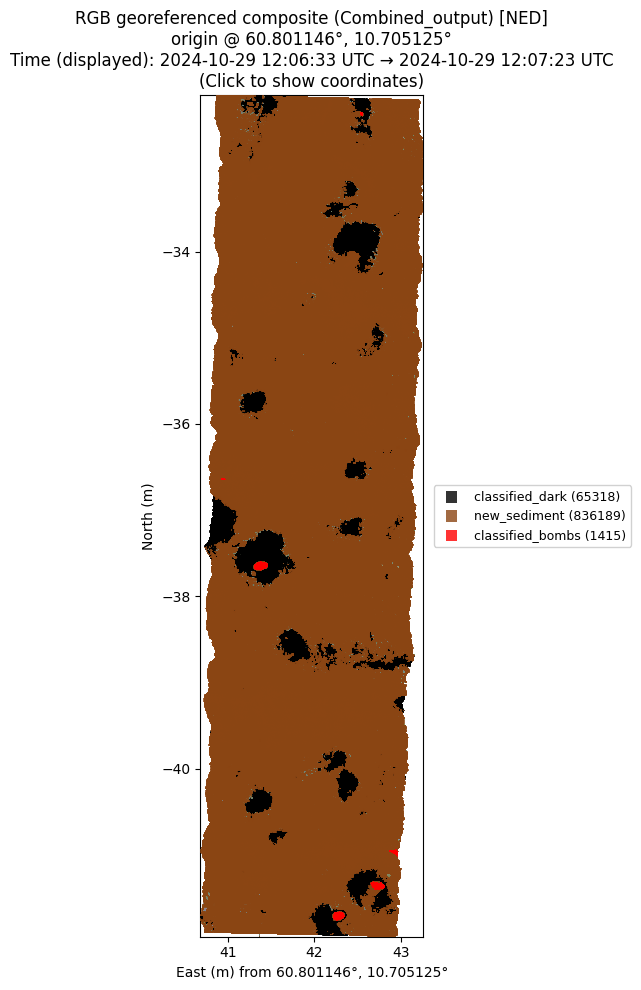

In [15]:
# Plot validation map (3 classes)
print("📊 Plotting validation map (3 classes)...")

validation_map_rois = {}
for class_name in merge_results["class_names"]:
    mask = merge_results["validation_map"] == class_name
    rows, cols = np.where(mask)
    pixels = [(col, row + config.UHI_TRACK_RANGE_5[0]) for row, col in zip(rows, cols)]
    if len(pixels) > 0:
        validation_map_rois[class_name] = pixels

print(f"ROIs created: {list(validation_map_rois.keys())}")
print(f"\n📊 Pixel counts:")
for class_name in sorted(validation_map_rois.keys()):
    print(f"   {class_name}: {len(validation_map_rois[class_name])} pixels")

cube.plot_georef(
    use_corrected=True,
    coordinate_system="NED",
    track_start=config.UHI_TRACK_RANGE_5[0],
    track_end=config.UHI_TRACK_RANGE_5[1],
    figsize=(40, 10),
    roi_collection=validation_map_rois,
    roi_marker_size=1,
    roi_legend_loc="outside",
    roi_marker_edgewidth=0,
    roi_legend_markersize=50,
)

## STEP 4: Validation

In [16]:
# Validate using the 3-class map
print("\n📊 STEP 4: VALIDATION")
print("=" * 60)

validation_results = cube.validate_classification(
    classification_map=merge_results["validation_map"],
    segment_start=config.UHI_TRACK_RANGE_5[0],
    segment_end=config.UHI_TRACK_RANGE_5[1],
    validation_rois=validation_rois,
    validation_class_mapping={
        "validation_sediment": "new_sediment",
        "validation_dark": "classified_dark",
        "validation_bombs": "classified_bombs",
    },
    quiet=False,
)

# Print summary
if validation_results:
    print(f"\n" + "=" * 60)
    print(f"📊 VALIDATION RESULTS")
    print(f"=" * 60)
    print(f"Overall Accuracy: {validation_results['accuracy']:.3f}")

    print(f"\n📋 Per-Class Results:")
    for class_name in merge_results["class_names"]:
        print(f"\n{class_name}:")
        print(
            f"  Precision: {validation_results['precision_per_class'][class_name]:.3f}"
        )
        print(f"  Recall:    {validation_results['recall_per_class'][class_name]:.3f}")
        print(f"  F1 Score:  {validation_results['f1_per_class'][class_name]:.3f}")
        print(
            f"  Support:   {validation_results['support_per_class'][class_name]} pixels"
        )


📊 STEP 4: VALIDATION
📊 CLASSIFICATION VALIDATION

   Classes in classification: ['classified_bombs', 'classified_dark', 'classified_unknown', 'new_sediment']
   Classes in validation: ['classified_bombs', 'classified_dark', 'new_sediment']

📈 Validation Results:
   Overall Accuracy: 0.758

   Per-Class Metrics:
   classified_bombs: P=1.000, R=0.458, F1=0.628, Support=454
   classified_dark: P=0.972, R=0.964, F1=0.968, Support=358
   classified_unknown: P=0.000, R=0.000, F1=0.000, Support=0
   new_sediment: P=0.529, R=0.993, F1=0.690, Support=268

📊 VALIDATION RESULTS
Overall Accuracy: 0.758

📋 Per-Class Results:

classified_bombs:
  Precision: 1.000
  Recall:    0.458
  F1 Score:  0.628
  Support:   454 pixels

classified_dark:
  Precision: 0.972
  Recall:    0.964
  F1 Score:  0.968
  Support:   358 pixels

new_sediment:
  Precision: 0.529
  Recall:    0.993
  F1 Score:  0.690
  Support:   268 pixels


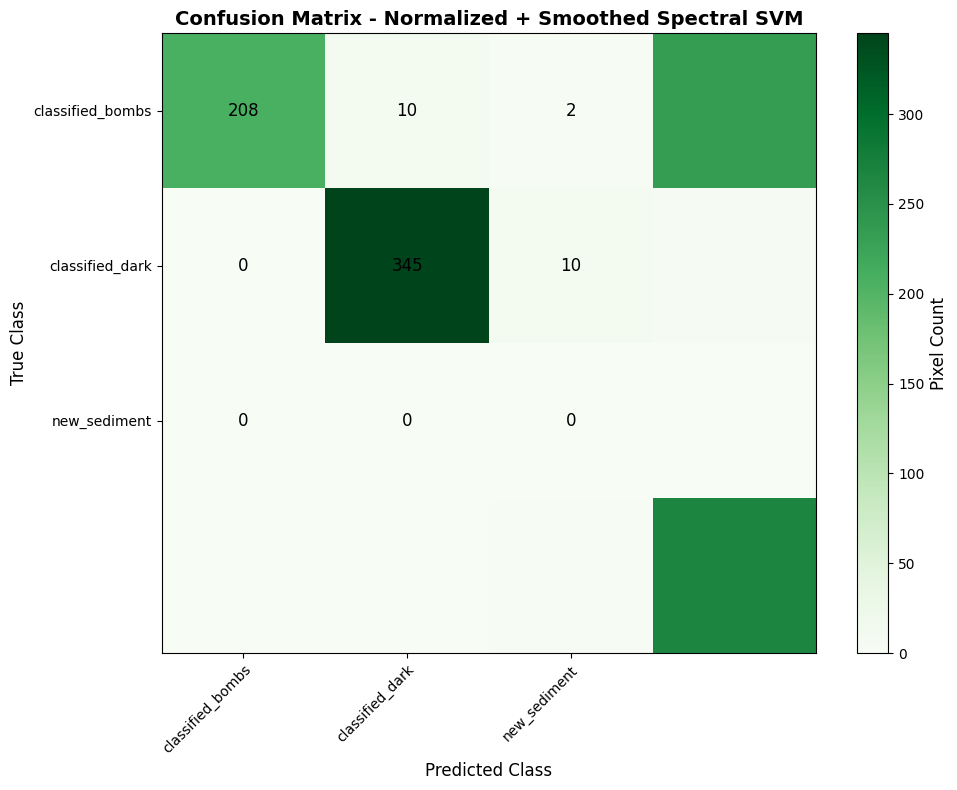


📊 Confusion Matrix (Normalized by True Class - Row %):
                        classified_bombs     classified_dark        new_sediment
--------------------------------------------------------------------------------
classified_bombs                   45.8%                2.2%                0.4%
classified_dark                     0.0%               96.4%                2.8%
new_sediment                        nan%                nan%                nan%


C:\Users\Erik Liu\AppData\Local\Temp\ipykernel_97264\2928226904.py:51: RuntimeWarning: invalid value encountered in divide
  cm_normalized = cm.astype("float") / cm.sum(axis=1)[:, np.newaxis] * 100


In [17]:
# Plot confusion matrix
if validation_results:
    import matplotlib.pyplot as plt

    cm = validation_results["confusion_matrix"]
    class_names = merge_results["class_names"]

    # Create figure
    fig, ax = plt.subplots(figsize=(10, 8))

    # Plot confusion matrix as image
    im = ax.imshow(cm, cmap="Greens", aspect="auto")

    # Add colorbar
    cbar = plt.colorbar(im, ax=ax)
    cbar.set_label("Pixel Count", fontsize=12)

    # Set ticks and labels
    ax.set_xticks(np.arange(len(class_names)))
    ax.set_yticks(np.arange(len(class_names)))
    ax.set_xticklabels(class_names)
    ax.set_yticklabels(class_names)

    # Rotate x-axis labels
    plt.setp(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")

    # Add text annotations
    for i in range(len(class_names)):
        for j in range(len(class_names)):
            text = ax.text(
                j,
                i,
                f"{cm[i, j]}",
                ha="center",
                va="center",
                color="black",
                fontsize=12,
            )

    ax.set_xlabel("Predicted Class", fontsize=12)
    ax.set_ylabel("True Class", fontsize=12)
    ax.set_title(
        "Confusion Matrix - Normalized + Smoothed Spectral SVM",
        fontsize=14,
        fontweight="bold",
    )
    plt.tight_layout()
    plt.show()

    # Print normalized confusion matrix (percentages)
    cm_normalized = cm.astype("float") / cm.sum(axis=1)[:, np.newaxis] * 100

    print(f"\n📊 Confusion Matrix (Normalized by True Class - Row %):")
    print(f"{'':20s}", end="")
    for pred_class in class_names:
        print(f"{pred_class:>20s}", end="")
    print()
    print("-" * (20 + 20 * len(class_names)))

    for i, true_class in enumerate(class_names):
        print(f"{true_class:20s}", end="")
        for j in range(len(class_names)):
            print(f"{cm_normalized[i, j]:19.1f}%", end="")
        print()

## Summary

**Complete workflow executed:**

1. ✅ **Classification** → `classified_bombs`, `classified_dark`, `classified_sediment` (3 classes)
2. ✅ **Filtering** → Creates `filtered_bombs`, `filtered_dark` for small clusters (5 classes total)
3. ✅ **Merge** → `classified_sediment + filtered_* → new_sediment` (3 classes for validation)
4. ✅ **Validation** → Compare against `validation_*` ROIs

**Key improvements:**
- Clear naming: `training_*` (for training) vs `classified_*` (predictions) vs `filtered_*` (removed pixels)
- No empty strings - all pixels have a class
- Can plot 5-class map to see what was filtered
- Can validate against 3-class map
- Morphological operations properly disabled (radius=0)